In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import joblib
import os

# Đảm bảo thư mục lưu ảnh đã tồn tại
os.makedirs('../artifacts/figures', exist_ok=True)
print("✅ Đã nạp xong thư viện và cấu hình thư mục.")

✅ Đã nạp xong thư viện và cấu hình thư mục.


In [2]:
# 1. Tải lại mô hình XGBoost tốt nhất từ file 04
model_path = '../artifacts/models/xgboost_best_model.pkl'
loaded_model = joblib.load(model_path)
print("✅ Đã tải mô hình XGBoost thành công!")

# 2. Tải lại dữ liệu X_test, y_test
# --- LƯU Ý: Nếu bạn đã lưu X_test, y_test ra file csv ở các bước trước, hãy dùng code đọc file ---
# Ví dụ:
# X_test = pd.read_csv('../data/processed/X_test.csv')
# y_test = pd.read_csv('../data/processed/y_test.csv')['target_column'] 

# (Nếu dữ liệu vẫn đang ở trên bộ nhớ (memory) dùng chung, bạn có thể bỏ qua dòng đọc file)

✅ Đã tải mô hình XGBoost thành công!


In [6]:
import sys
import os

# 1. Khai báo đường dẫn để Python tìm thấy thư mục src của bạn
sys.path.append(os.path.abspath('..'))
from src.models.models import RetailReturnModeler

# 2. Khởi tạo lại class modeler
modeler = RetailReturnModeler()

# 3. Dùng hàm có sẵn của bạn để load lại dữ liệu
X_train, X_test, y_train, y_test = modeler.load_and_split_data()

print("✅ Đã nạp thành công X_test và y_test từ module src!")

✅ Đã nạp thành công X_test và y_test từ module src!


In [7]:
# Dự đoán nhãn (0: Không trả hàng, 1: Có trả hàng)
y_pred = loaded_model.predict(X_test)

# Dự đoán xác suất (Dùng để vẽ các biểu đồ nâng cao như ROC-AUC nếu cần)
y_pred_proba = loaded_model.predict_proba(X_test)[:, 1] 

print("✅ Đã hoàn tất dự đoán trên tập Test.")

✅ Đã hoàn tất dự đoán trên tập Test.


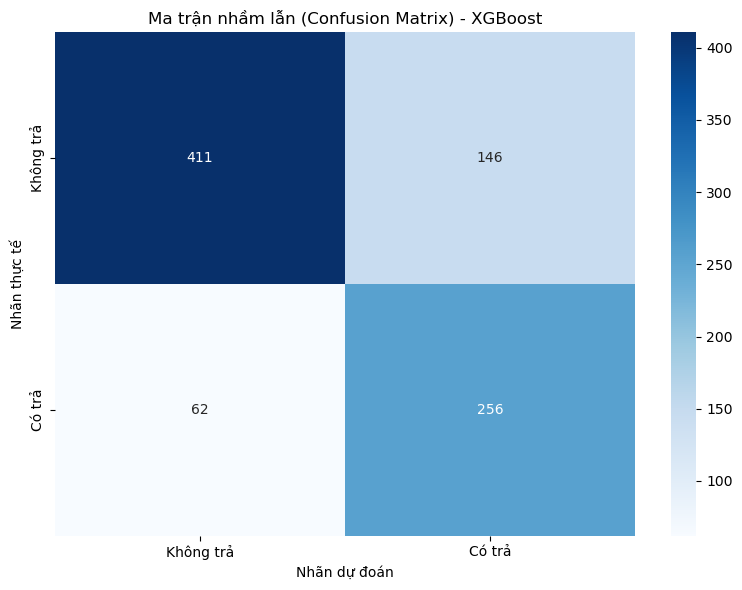

In [8]:
# Tính toán Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)

# Vẽ biểu đồ Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Không trả', 'Có trả'], 
            yticklabels=['Không trả', 'Có trả'])

plt.title('Ma trận nhầm lẫn (Confusion Matrix) - XGBoost')
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.tight_layout()

# Lưu ảnh và hiển thị
plt.savefig('../artifacts/figures/confusion_matrix_xgb.png')
plt.show()

In [9]:
# In báo cáo đánh giá chi tiết
print("BÁO CÁO HIỆU SUẤT MÔ HÌNH (XGBoost):")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=['Không trả', 'Có trả']))

BÁO CÁO HIỆU SUẤT MÔ HÌNH (XGBoost):
--------------------------------------------------
              precision    recall  f1-score   support

   Không trả       0.87      0.74      0.80       557
      Có trả       0.64      0.81      0.71       318

    accuracy                           0.76       875
   macro avg       0.75      0.77      0.75       875
weighted avg       0.78      0.76      0.77       875

